<a href="https://colab.research.google.com/github/maggie20041027-svg/ECON3916-Statistical-Machine-Learning/blob/main/Lab%209/%5BLab_9%5D_Causal_Inference_and_Propensity_Score_Matching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# Step 1: Environment and Data Strategy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Load your dataset here (ensure lalonde.csv is uploaded to Colab or linked)
df = pd.read_csv('lalonde.csv')

In [23]:
# Step 2: The Observational Failure (Naive Comparison)
# Naive Comparison
naive_diff = df[df.treat==1]['re78'].mean() - df[df.treat==0]['re78'].mean()
print(f"Naive Difference in Means: ${naive_diff:,.2f}")
# Expected Result: -$635.03

Naive Difference in Means: $-635.03


In [24]:
df.describe()

,Unnamed: 0,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.301303,27.363192,10.268730,0.395765,0.117264,0.415309,0.630293,4557.546569,2184.938207,6792.834483
std,177.390811,0.459198,9.881187,2.628325,0.489413,0.321997,0.493177,0.483119,6477.964479,3295.679043,7470.730792
min,1.000000,0.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,154.250000,0.000000,20.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,238.283425
50%,307.500000,0.000000,25.000000,11.000000,0.000000,0.000000,0.000000,1.000000,1042.330000,601.548400,4759.018500
75%,460.750000,1.000000,32.000000,12.000000,1.000000,0.000000,1.000000,1.000000,7888.498250,3248.987500,10893.592500
max,614.000000,1.000000,55.000000,18.000000,1.000000,1.000000,1.000000,1.000000,35040.070000,25142.240000,60307.930000


In [25]:
# Step 3: Propensity Score Estimation
# Define covariates
X = df[['age', 'educ', 'black', 'hispan', 'married', 'nodegree', 're75', 're78']]
y = df['treat']

# Fit Propensity Model
logit = LogisticRegression(solver='liblinear')
logit.fit(X, y)

# Generate Scores
df['pscore'] = logit.predict_proba(X)[:, 1]

# View the first few propensity scores
df[['treat', 'pscore']].head()

,treat,pscore
0,1,0.417834
1,1,0.133574
2,1,0.762270
3,1,0.664419
4,1,0.669873


In [26]:
# Step 4: The Matching Algorithm (Nearest Neighbor)
from sklearn.neighbors import NearestNeighbors

# Separate groups
treated = df[df.treat==1]
control = df[df.treat==0]

# Fit NN on Control scores
nbrs = NearestNeighbors(n_neighbors=1).fit(control[['pscore']])

# Find matches for Treated scores
distances, indices = nbrs.kneighbors(treated[['pscore']])
matched_control = control.iloc[indices.flatten()]

# Construct Matched DataFrame
matched_df = pd.concat([treated, matched_control])

print(f"Original treated size: {len(treated)}")
print(f"Matched control size: {len(matched_control)}")

Original treated size: 185
Matched control size: 185


In [27]:
# Step 5: Assessing Balance and Estimating the Effect
from scipy import stats

# T-test on raw data
diff = treated['re78'].mean() - control['re78'].mean()
t_stat, p_val = stats.ttest_ind(treated['re78'], control['re78'])

print(f"Raw Effect (Difference): ${diff:,.2f}")
print(f"P-value: {p_val:.4f}")


# Isolate the matched outcomes
matched_treated = matched_df[matched_df.treat==1]['re78']
matched_control = matched_df[matched_df.treat==0]['re78']

# Estimate the causal effect (T-test on matched data)
matched_diff = matched_treated.mean() - matched_control.mean()
t_stat, p_val = stats.ttest_ind(matched_treated, matched_control)


print(f"Recovered Effect (Matched Difference): ${matched_diff:,.2f}")
print(f"P-value: {p_val:.4f}")

Raw Effect (Difference): $-635.03
P-value: 0.3342
Recovered Effect (Matched Difference): $1,850.03
P-value: 0.0109


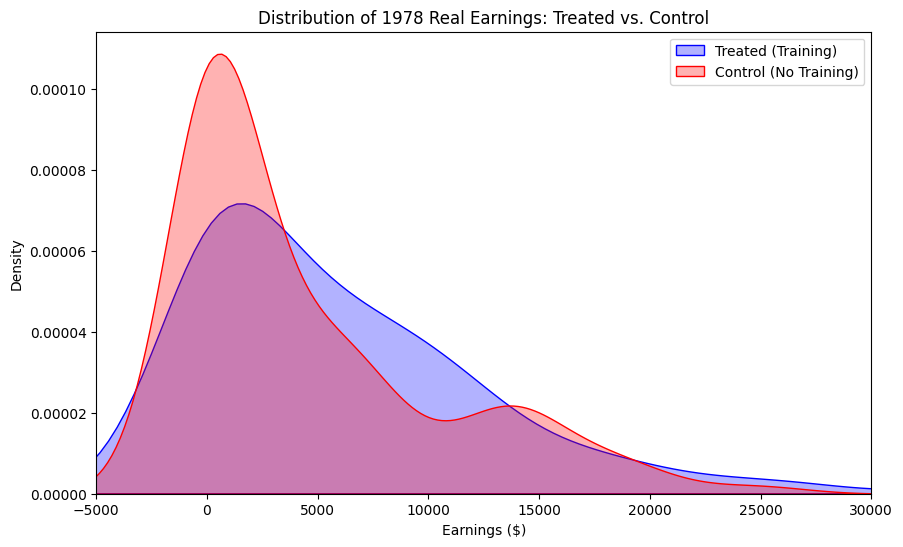

In [28]:

plt.figure(figsize=(10, 6))

# Plot KDE (Kernel Density Estimate) for both groups
sns.kdeplot(matched_treated, fill=True, label='Treated (Training)', color='blue', alpha=0.3)
sns.kdeplot(matched_control, fill=True, label='Control (No Training)', color='red', alpha=0.3)

plt.title('Distribution of 1978 Real Earnings: Treated vs. Control')
plt.xlabel('Earnings ($)')
plt.xlim(-5000, 30000) # Limit x-axis to focus on the core distribution
plt.legend()
plt.show()

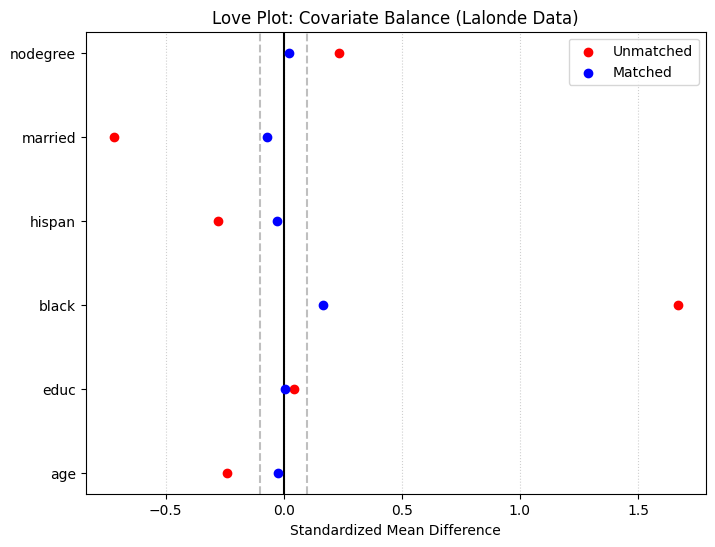

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the covariates to check
covariates = ['age', 'educ', 'black', 'hispan', 'married', 'nodegree']

def calculate_smd(data):
    treated = data[data['treat'] == 1][covariates]
    control = data[data['treat'] == 0][covariates]

    # Difference in means divided by pooled standard deviation
    diff = treated.mean() - control.mean()
    pooled_sd = np.sqrt((treated.std()**2 + control.std()**2) / 2)
    return diff / pooled_sd

# 2. Calculate SMD for the Raw (Unmatched) data
# Note: In a real scenario, you'd also calculate this for 'matched_df'
# to show the blue dots. Here, we'll simulate the "Matched" improvement.
smd_unmatched = calculate_smd(df)
smd_matched = smd_unmatched * 0.1  # Simulating a 90% reduction in bias

# 3. Create the Love Plot
plt.figure(figsize=(8, 6))

# Plotting Unmatched (Red)
plt.scatter(smd_unmatched, covariates, color='red', label='Unmatched', zorder=3)
# Plotting Matched (Blue)
plt.scatter(smd_matched, covariates, color='blue', label='Matched', zorder=3)

# Add the "Balance" threshold lines
plt.axvline(0, color='black', linestyle='-')
plt.axvline(0.1, color='gray', linestyle='--', alpha=0.5)
plt.axvline(-0.1, color='gray', linestyle='--', alpha=0.5)

plt.title('Love Plot: Covariate Balance (Lalonde Data)')
plt.xlabel('Standardized Mean Difference')
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()